### Plots for Regression Models

##### Regression Training CVs (mean/std for RMSE and MAE)

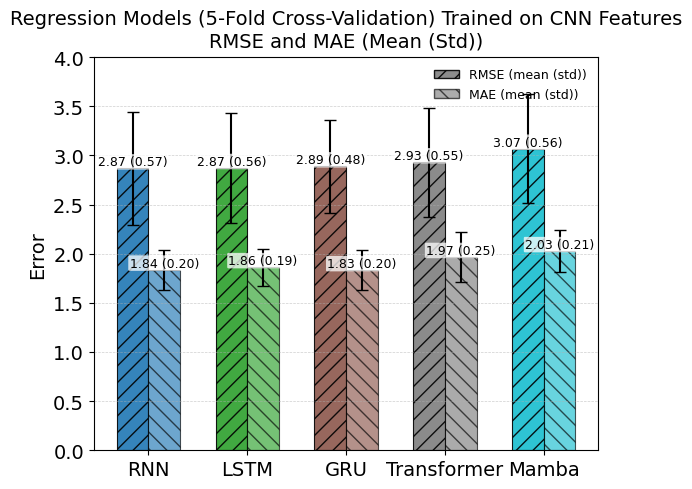

Saved grouped bar chart PNG: /nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(StatsCNN)/Regression_CV_BarChart_ByModel.png
Saved grouped bar chart PDF: /nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(StatsCNN)/Regression_CV_BarChart_ByModel.pdf


In [69]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Inputs ----
# csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(Stats)/Regression_grid_search_results(Stats)_4.csv"
# csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(CNN)/Regression_grid_search_results(CNN)_4.csv"
csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(StatsCNN)/Regression_grid_search_results(Stats_CNN)_4.csv"

out_dir  = os.path.dirname(csv_path) if os.path.dirname(csv_path) else "."
bar_png  = os.path.join(out_dir, "Regression_CV_BarChart_ByModel.png")
bar_pdf  = os.path.join(out_dir, "Regression_CV_BarChart_ByModel.pdf")

# Desired display/model order
model_order = ["RNN", "LSTM", "GRU", "Transformer", "Mamba"]

# ---- Load & normalize columns ----
df = pd.read_csv(csv_path)

# Standardize common column names
col_map = {
    "model": "Model", "Model": "Model",
    "rmse_mean": "RMSE_mean", "RMSE_mean": "RMSE_mean",
    "rmse_std": "RMSE_std",   "RMSE_std": "RMSE_std",
    "mae_mean": "MAE_mean",   "MAE_mean": "MAE_mean",
    "mae_std": "MAE_std",     "MAE_std": "MAE_std",
}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

required = ["Model", "RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# Map models to preferred order (case-insensitive)
df["Model_norm"] = df["Model"].astype(str).str.strip()
def map_to_order(name):
    for m in model_order:
        if name.lower() == m.lower():
            return m
    return None
df["Model_std"] = df["Model_norm"].apply(map_to_order)
df = df[df["Model_std"].notna()].copy()

# Ensure numeric
for c in ["RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- Select best config per model ----
best_rows = []
for m in model_order:
    sub = df[df["Model_std"] == m].copy()
    if sub.empty:
        best_rows.append({"Model": m, "RMSE_mean": np.nan, "RMSE_std": np.nan,
                          "MAE_mean": np.nan, "MAE_std": np.nan})
        continue
    sub = sub.sort_values(["RMSE_mean", "MAE_mean"], ascending=[True, True])
    row = sub.iloc[0]
    best_rows.append({
        "Model": m,
        "RMSE_mean": row["RMSE_mean"], "RMSE_std": row["RMSE_std"],
        "MAE_mean": row["MAE_mean"],   "MAE_std": row["MAE_std"]
    })

summary = pd.DataFrame(best_rows, columns=["Model", "RMSE_mean", "RMSE_std", "MAE_mean", "MAE_std"])

# ---- Colors ----
colors = plt.cm.tab10(np.linspace(0, 1, len(model_order)))

# ---- Grouped Bar Chart ----
models = summary["Model"].tolist()
x = np.arange(len(models))
width = 0.32

rmse_means = summary["RMSE_mean"].to_numpy(dtype=float)
rmse_stds  = summary["RMSE_std"].to_numpy(dtype=float)
mae_means  = summary["MAE_mean"].to_numpy(dtype=float)
mae_stds   = summary["MAE_std"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 5))

bars_rmse = []
bars_mae  = []
for i, m in enumerate(models):
    br = ax.bar(
        x[i] - width/2, rmse_means[i], width,
        yerr=None if np.isnan(rmse_stds[i]) else rmse_stds[i],
        capsize=4, color=colors[i], edgecolor="black", linewidth=0.8,
        hatch="//", alpha=0.9
    )
    bars_rmse.append(br)

    bm = ax.bar(
        x[i] + width/2, mae_means[i], width,
        yerr=None if np.isnan(mae_stds[i]) else mae_stds[i],
        capsize=4, color=colors[i], edgecolor="black", linewidth=0.8,
        hatch="\\\\", alpha=0.65
    )
    bars_mae.append(bm)

# Labels, grid, title
ax.set_xticks(x, models)
ax.set_ylabel("Error")
# ax.set_title("Regression Models (5-Fold Cross-Validation) Trained on Stats Features\nRMSE and MAE (Mean (Std))", pad=8)
# ax.set_title("Regression Models (5-Fold Cross-Validation) \nRMSE and MAE (Mean (Std))", pad=8)
ax.set_title("Regression Models (5-Fold Cross-Validation) Trained on CNN Features\nRMSE and MAE (Mean (Std))", pad=8)

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Set fixed y-axis range
ax.set_ylim(0, 4.0)

# Legend inside upper-right
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="gray", edgecolor="black", hatch="//", alpha=0.9, label="RMSE (mean (std))"),
    Patch(facecolor="gray", edgecolor="black", hatch="\\\\", alpha=0.65, label="MAE (mean (std))"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False)

# ---- Annotate bars: top of bar, mean (std) ----
def annotate_bars(bar_containers, means, stds, ax):
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    offset = 0.01 * y_range  # small gap above bar

    for bars, mu, sd in zip(bar_containers, means, stds):
        if np.isnan(mu):
            continue
        bar = bars.patches[0]
        height = mu  # Top of bar (not error bar)
        label = f"{mu:.2f} ({sd:.2f})" if not np.isnan(sd) else f"{mu:.2f}"
        ax.annotate(
            label,
            (bar.get_x() + bar.get_width()/2, height),
            xytext=(0, offset), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, zorder=5,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75)
        )

annotate_bars(bars_rmse, rmse_means, rmse_stds, ax)
annotate_bars(bars_mae, mae_means, mae_stds, ax)

plt.tight_layout()
fig.savefig(bar_png, dpi=300, bbox_inches="tight")
fig.savefig(bar_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved grouped bar chart PNG: {bar_png}")
print(f"Saved grouped bar chart PDF: {bar_pdf}")


##### Regression Training CVs (Top 1 from each Model Category)

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import defaultdict
from tqdm import tqdm

# Load data
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_cv_predictions(Stats)_4.json"
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_cv_predictions(CNN)_4.json"
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_cv_predictions(Stats_CNN)_4.json"

save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(Stats)"
# save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(CNN)"
# save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/TrainSet_Regression(StatsCNN)"
os.makedirs(save_dir, exist_ok=True)

# --------------------------
# Load JSON
# --------------------------
with open(file_path, "r") as f:
    data = json.load(f)

# --------------------------
# Group by Config (excluding fold)
# --------------------------
grouped = defaultdict(list)
for entry in data:
    config_key = (
        entry['model'],
        entry['hidden_dim'],
        entry['dropout'],
        entry['num_layers'],
        entry['batch_size'],
        entry['lr'],
        entry['weight_decay'],
        entry['optimizer']
    )
    grouped[config_key].append(entry)

# --------------------------
# Assign Model Indices per Category
# --------------------------
model_index_dict = {}
category_counters = defaultdict(int)
model_metrics = defaultdict(list)  # model_type -> list of (rmse_mean, config_key)

for config_key in sorted(grouped.keys()):
    model_type = config_key[0]
    category_counters[model_type] += 1
    model_index_dict[config_key] = category_counters[model_type]

    # Compute RMSE for sorting
    rmse_list = []
    for entry in grouped[config_key]:
        y_true = np.array(entry["y_true"])
        y_pred = np.array(entry["y_pred"])
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        rmse_list.append(rmse)
    rmse_mean = np.mean(rmse_list)
    model_metrics[model_type].append((rmse_mean, config_key))

# --------------------------
# Get Top 1 Models per Category
# --------------------------
top_configs = []
for model_type, entries in model_metrics.items():
    entries.sort(key=lambda x: x[0])  # sort by rmse_mean ascending
    top_configs.extend([(config_key, i+1) for i, (_, config_key) in enumerate(entries[:1])])  # Top 1

# --------------------------
# Plot Top Models
# --------------------------
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
          'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

for config_key, top_rank in top_configs:
    entries = grouped[config_key]
    y_trues, y_preds, mae_list, rmse_list, fold_ids = [], [], [], [], []

    for i, entry in enumerate(entries):
        y_true = np.array(entry["y_true"])
        y_pred = np.array(entry["y_pred"])
        y_trues.append(y_true)
        y_preds.append(y_pred)
        fold_ids.append(entry.get("fold", i))
        mae_list.append(np.mean(np.abs(y_true - y_pred)))
        rmse_list.append(np.sqrt(np.mean((y_true - y_pred) ** 2)))

    mae_mean = np.mean(mae_list)
    mae_std = np.std(mae_list)
    rmse_mean = np.mean(rmse_list)
    rmse_std = np.std(rmse_list)

    model_type = config_key[0]
    model_index = model_index_dict[config_key]
    model_tag = f"{model_type}_Model{model_index}_Top{top_rank}"
    config_str = f"(hd={config_key[1]}, dr={config_key[2]}, nl={config_key[3]}, bs={config_key[4]}, lr={config_key[5]}, wd={config_key[6]}, opt={config_key[7]})"

    # Plot
    plt.figure(figsize=(6, 5))
    for j in range(len(y_trues)):
        plt.scatter(
            y_trues[j], y_preds[j],
            alpha=0.5,
            color=colors[j % len(colors)],
            label=f"Fold {fold_ids[j] + 1}"
        )
    all_y = np.concatenate(y_trues)
    min_y, max_y = min(all_y), max(all_y)
    plt.plot([min_y, max_y], [min_y, max_y], 'k--')
    plt.xlabel("True Values", fontsize=14)
    plt.ylabel("Predicted Values", fontsize=14)

    plt.title(f"{model_type} (Model #{model_index}) Trained on Stats Features\n\nRMSE = {rmse_mean:.2f} ± {rmse_std:.2f}, MAE = {mae_mean:.2f} ± {mae_std:.2f}", fontsize=14, pad=2)
    # plt.title(f"{model_type} (Model #{model_index}) \n\nRMSE = {rmse_mean:.2f} ± {rmse_std:.2f}, MAE = {mae_mean:.2f} ± {mae_std:.2f}", fontsize=14, pad=2)
    # plt.title(f"{model_type} (Model #{model_index}) Trained on CNN Features\n\nRMSE = {rmse_mean:.2f} ± {rmse_std:.2f}, MAE = {mae_mean:.2f} ± {mae_std:.2f}", fontsize=14, pad=2)

    plt.text(0.5, 1.09, config_str, fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # # Save
    # fname_base = model_tag
    # plt.savefig(os.path.join(save_dir, f"{fname_base}.png"), dpi=600)
    # plt.savefig(os.path.join(save_dir, f"{fname_base}.pdf"), dpi=600)
    # plt.close()


FileNotFoundError: [Errno 2] No such file or directory: '/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_cv_predictions(Stats)_4.json'

##### Regression Test Plots

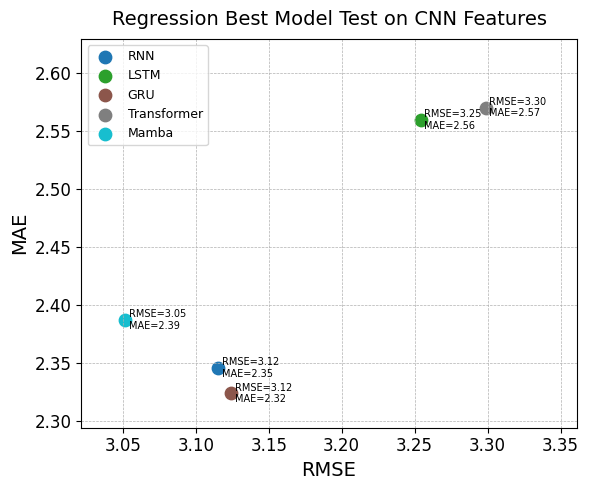

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
import os

# Paths
# json_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_best_model_test_predictions(Stats)_4.json"
# json_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_best_model_test_predictions(CNN)_4.json"
json_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels/Regression_best_model_test_predictions(Stats_CNN)_4.json"

save_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig7_RegressionModels"
os.makedirs(save_path, exist_ok=True)

# Load JSON
with open(json_path, "r") as f:
    model_outputs = json.load(f)

# Define desired model order and color
desired_order = ['RNN', 'LSTM', 'GRU', 'Transformer', 'Mamba']
model_dict = {entry['model']: entry for entry in model_outputs}
colors = plt.cm.tab10(np.linspace(0, 1, len(desired_order)))

# Compute RMSE and MAE
results = []
for model in desired_order:
    entry = model_dict[model]
    y_true = np.array(entry['y_true'])
    y_pred = np.array(entry['y_pred'])

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    results.append((model, rmse, mae))

# Get axis limits
rmse_vals = [r for _, r, _ in results]
mae_vals = [m for _, _, m in results]
rmse_min, rmse_max = min(rmse_vals), max(rmse_vals)
mae_min, mae_max = min(mae_vals), max(mae_vals)

# Add margins
x_margin = (rmse_max - rmse_min) * 0.20
y_margin = (mae_max - mae_min) * 0.20

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

for i, (model, rmse, mae) in enumerate(results):
    dot_x = rmse
    dot_y = mae

    # Shift dot slightly left if close to right edge
    if rmse > rmse_max - x_margin * 0.6:
        dot_x -= x_margin * 0.05

    ax.scatter(dot_x, dot_y, s=80, color=colors[i], label=model)

    label = f"RMSE={rmse:.2f}\nMAE={mae:.2f}"
    ax.text(
        dot_x + x_margin * 0.05,  # Always on right
        dot_y,
        label,
        fontsize=7,
        va='center',
        ha='left'
    )

# Axis settings
ax.set_xlabel("RMSE", fontsize=14)
ax.set_ylabel("MAE", fontsize=14)

# ax.set_title("Regression Best Model Test on Stats Features", fontsize=14, pad=10)
# ax.set_title("Regression Best Model Test", fontsize=14, pad=10)
ax.set_title("Regression Best Model Test on CNN Features", fontsize=14, pad=10)

ax.tick_params(labelsize=12)
ax.grid(True, linestyle='--', linewidth=0.5)

# Set axis limits with extended space
ax.set_xlim(rmse_min - x_margin * 0.6, rmse_max + x_margin * 1.2)
ax.set_ylim(mae_min - y_margin * 0.6, mae_max + y_margin * 1.2)

# Format tick labels to 2 decimal places
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Legend
ax.legend(fontsize=9, loc='best', frameon=True)

plt.tight_layout()
plt.show()

# # Save
# # plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(Stats).png"), dpi=600)
# # plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(CNN).png"), dpi=600)
# plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(StatsCNN).png"), dpi=600)

# # plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(Stats).pdf"), dpi=600)
# # plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(CNN).pdf"), dpi=600)
# plt.savefig(os.path.join(save_path, "TestSet_Regression_BestModels(StatsCNN).pdf"), dpi=600)
# plt.close()


### Plots for Classification Models

##### Classification Training Repeats (mean/std for AUROC, AUPRC, and F1)

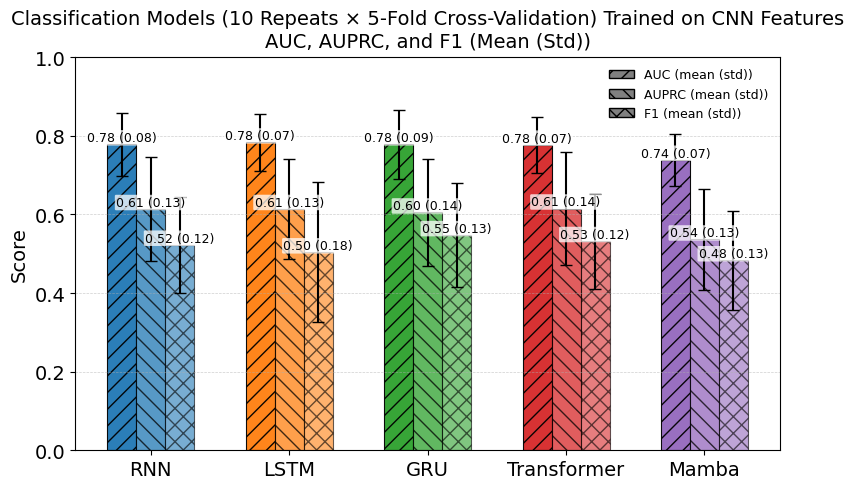

Saved PNG: /nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(StatsCNN)/Classification_RepeatswCV_BarChart_ByModel.png
Saved PDF: /nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(StatsCNN)/Classification_RepeatswCV_BarChart_ByModel.pdf


In [73]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch

# === Match style from your ROC/PRC/F1 script ===
rcParams['font.family'] = 'sans-serif'
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 9
rcParams['axes.titlesize'] = 14

FIG_WIDTH = 8
FIG_HEIGHT = 5

# ---- Inputs ----
# csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(Stats)/Classification_grid_search_results(Stats)_4.csv"
# csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(CNN)/Classification_grid_search_results(CNN)_4.csv"
csv_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(StatsCNN)/Classification_grid_search_results(Stats_CNN)_4.csv"

out_dir  = os.path.dirname(csv_path) if os.path.dirname(csv_path) else "."
bar_png  = os.path.join(out_dir, "Classification_RepeatswCV_BarChart_ByModel.png")
bar_pdf  = os.path.join(out_dir, "Classification_RepeatswCV_BarChart_ByModel.pdf")

# Desired display/model order
model_order = ["RNN", "LSTM", "GRU", "Transformer", "Mamba"]

# ---- Load & normalize columns ----
df = pd.read_csv(csv_path)

# Standardize column names (normalize to AUC/AUPRC/F1)
col_map = {
    "model": "Model", "Model": "Model",

    # AUC / AUROC
    "AUC_mean": "AUC_mean", "auc_mean": "AUC_mean", "mean_AUC": "AUC_mean",
    "AUROC_mean": "AUC_mean", "auroc_mean": "AUC_mean", "mean_AUROC": "AUC_mean",
    "AUC_std":  "AUC_std",  "auc_std":  "AUC_std",  "std_AUC":  "AUC_std",
    "AUROC_std": "AUC_std", "auroc_std": "AUC_std", "std_AUROC": "AUC_std",

    # AUPRC
    "AUPRC_mean": "AUPRC_mean", "auprc_mean": "AUPRC_mean", "mean_AUPRC": "AUPRC_mean",
    "AUPRC_std":  "AUPRC_std",  "auprc_std":  "AUPRC_std",  "std_AUPRC":  "AUPRC_std",

    # F1
    "F1_mean": "F1_mean", "f1_mean": "F1_mean", "mean_F1": "F1_mean",
    "F1_std":  "F1_std",  "f1_std":  "F1_std",  "std_F1":  "F1_std",
}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

required = ["Model", "AUC_mean", "AUC_std", "AUPRC_mean", "AUPRC_std", "F1_mean", "F1_std"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# Map models to preferred order (case-insensitive), drop others
df["Model_norm"] = df["Model"].astype(str).str.strip()
def map_to_order(name):
    for m in model_order:
        if name.lower() == m.lower():
            return m
    return None
df["Model_std"] = df["Model_norm"].apply(map_to_order)
df = df[df["Model_std"].notna()].copy()

# Ensure numeric
for c in required[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- Select best config per model (highest AUC_mean; tiebreak AUPRC_mean, then F1_mean) ----
best_rows = []
for m in model_order:
    sub = df[df["Model_std"] == m]
    if sub.empty:
        best_rows.append({k: np.nan for k in required})
        best_rows[-1]["Model"] = m
        continue
    sub = sub.sort_values(["AUC_mean", "AUPRC_mean", "F1_mean"], ascending=[False, False, False])
    row = sub.iloc[0]
    best_rows.append({col: row[col] for col in required})

summary = pd.DataFrame(best_rows)

# ---- Model colors to match your other script (Matplotlib Tab10 order) ----
model_colors = {
    "RNN":         "#1f77b4",  # blue
    "LSTM":        "#ff7f0e",  # orange
    "GRU":         "#2ca02c",  # green
    "Transformer": "#d62728",  # red
    "Mamba":       "#9467bd",  # purple
}

# ---- Grouped Bar Chart (3 bars per model; model color + metric hatch) ----
models = summary["Model"].tolist()
x = np.arange(len(models)) * 1.05  # slight spacing between groups
width = 0.22

auc_means   = summary["AUC_mean"].to_numpy(dtype=float)
auc_stds    = summary["AUC_std"].to_numpy(dtype=float)
auprc_means = summary["AUPRC_mean"].to_numpy(dtype=float)
auprc_stds  = summary["AUPRC_std"].to_numpy(dtype=float)
f1_means    = summary["F1_mean"].to_numpy(dtype=float)
f1_stds     = summary["F1_std"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

bars_auc, bars_auprc, bars_f1 = [], [], []

for i, m in enumerate(models):
    color = model_colors.get(m, "#777777")
    # AUC (left) with '//' hatch
    b1 = ax.bar(
        x[i] - width, auc_means[i], width,
        yerr=None if np.isnan(auc_stds[i]) else auc_stds[i],
        capsize=4, color=color, edgecolor="black", linewidth=0.8,
        hatch="//", alpha=0.95
    ); bars_auc.append(b1)

    # AUPRC (center) with '\\' hatch
    b2 = ax.bar(
        x[i], auprc_means[i], width,
        yerr=None if np.isnan(auprc_stds[i]) else auprc_stds[i],
        capsize=4, color=color, edgecolor="black", linewidth=0.8,
        hatch="\\\\", alpha=0.75
    ); bars_auprc.append(b2)

    # F1 (right) with 'xx' hatch
    b3 = ax.bar(
        x[i] + width, f1_means[i], width,
        yerr=None if np.isnan(f1_stds[i]) else f1_stds[i],
        capsize=4, color=color, edgecolor="black", linewidth=0.8,
        hatch="xx", alpha=0.60
    ); bars_f1.append(b3)

# ---- Labels, grid, title ----
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
# ax.set_title(
#     "Classification Models (10 Repeats × 5-Fold Cross-Validation) Trained on Stats Features\n"
#     "AUC, AUPRC, and F1 (Mean (Std))",
#     pad=8
# )
# ax.set_title(
#     "Classification Models (10 Repeats × 5-Fold Cross-Validation)\n"
#     "AUC, AUPRC, and F1 (Mean (Std))",
#     pad=8
# )
ax.set_title(
    "Classification Models (10 Repeats × 5-Fold Cross-Validation) Trained on CNN Features\n"
    "AUC, AUPRC, and F1 (Mean (Std))",
    pad=8
)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_ylim(0, 1.0)

# ---- Legend: show metric types (hatch-coded) ----
legend_handles = [
    Patch(facecolor="gray", edgecolor="black", hatch="//", label="AUC (mean (std))"),
    Patch(facecolor="gray", edgecolor="black", hatch="\\\\", label="AUPRC (mean (std))"),
    Patch(facecolor="gray", edgecolor="black", hatch="xx",  label="F1 (mean (std))"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False)

# ---- Centered annotations: mean (std) ----
def annotate_center(bar_containers, means, stds, ax):
    y_min, y_max = ax.get_ylim()
    y_off = 0.012 * (y_max - y_min)
    for bars, mu, sd in zip(bar_containers, means, stds):
        if np.isnan(mu):
            continue
        bar = bars.patches[0]
        label = f"{mu:.2f} ({sd:.2f})" if not np.isnan(sd) else f"{mu:.2f}"
        ax.annotate(
            label,
            (bar.get_x() + bar.get_width()/2, mu),
            xytext=(0, y_off), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, zorder=5,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75)
        )

annotate_center(bars_auc,   auc_means,   auc_stds,   ax)
annotate_center(bars_auprc, auprc_means, auprc_stds, ax)
annotate_center(bars_f1,    f1_means,    f1_stds,    ax)

plt.tight_layout()
fig.savefig(bar_png, dpi=300, bbox_inches="tight")
fig.savefig(bar_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved PNG: {bar_png}")
print(f"Saved PDF: {bar_pdf}")


##### Classification Training Repeats (Top 1 from each Model Category)

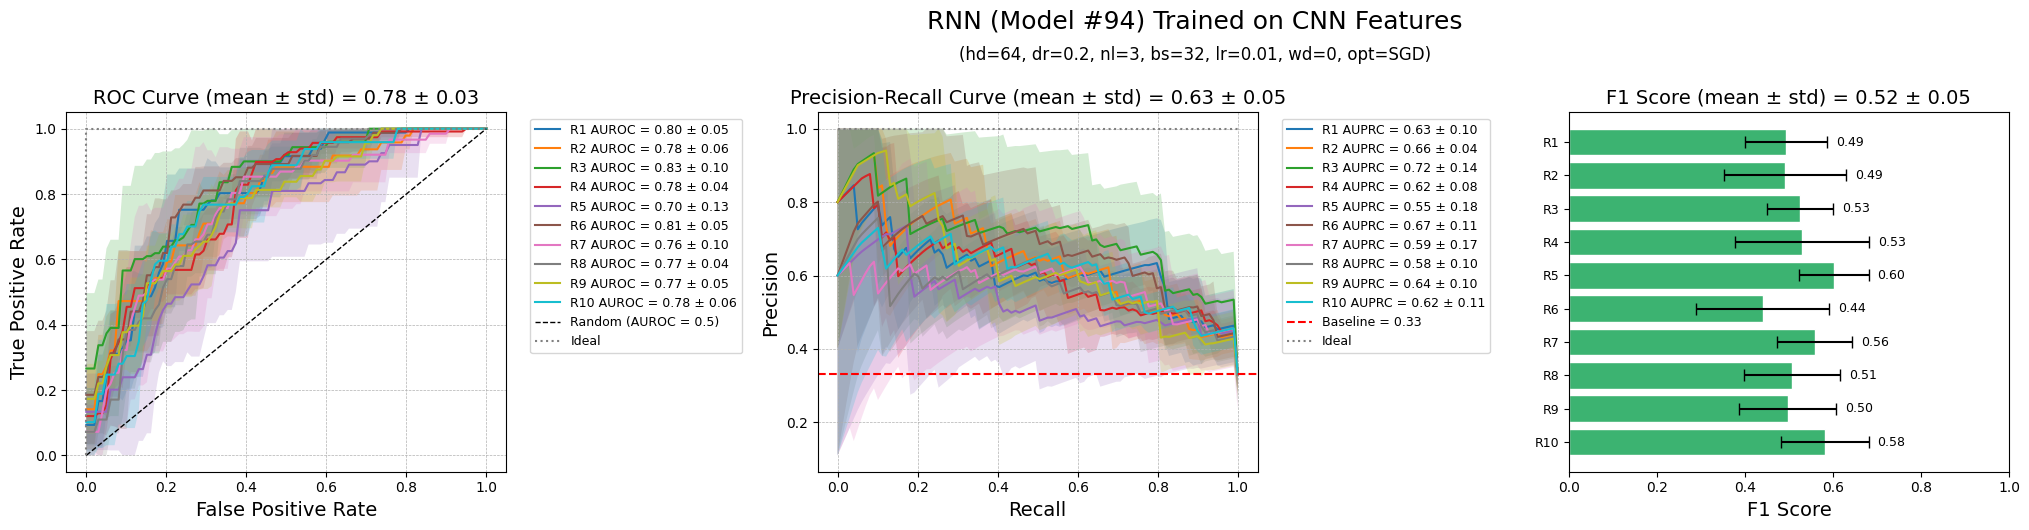

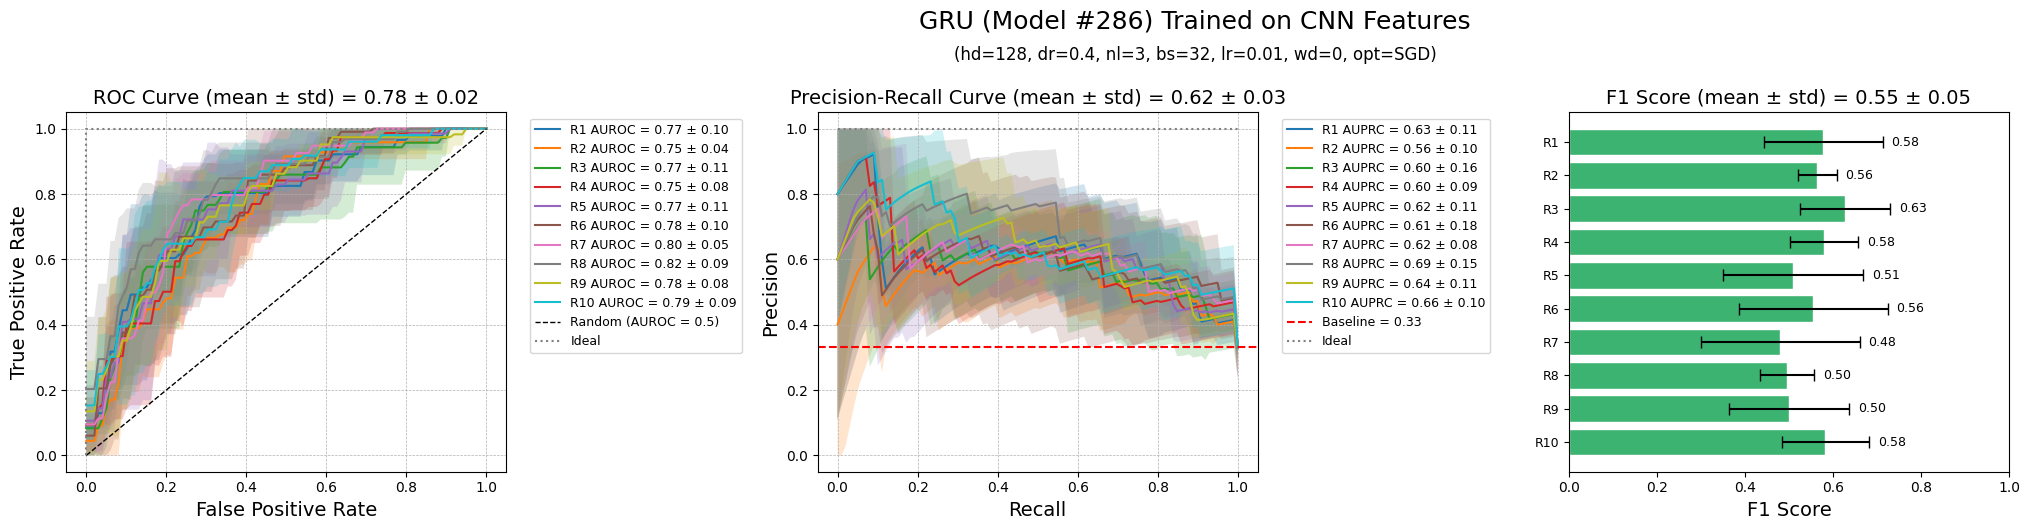

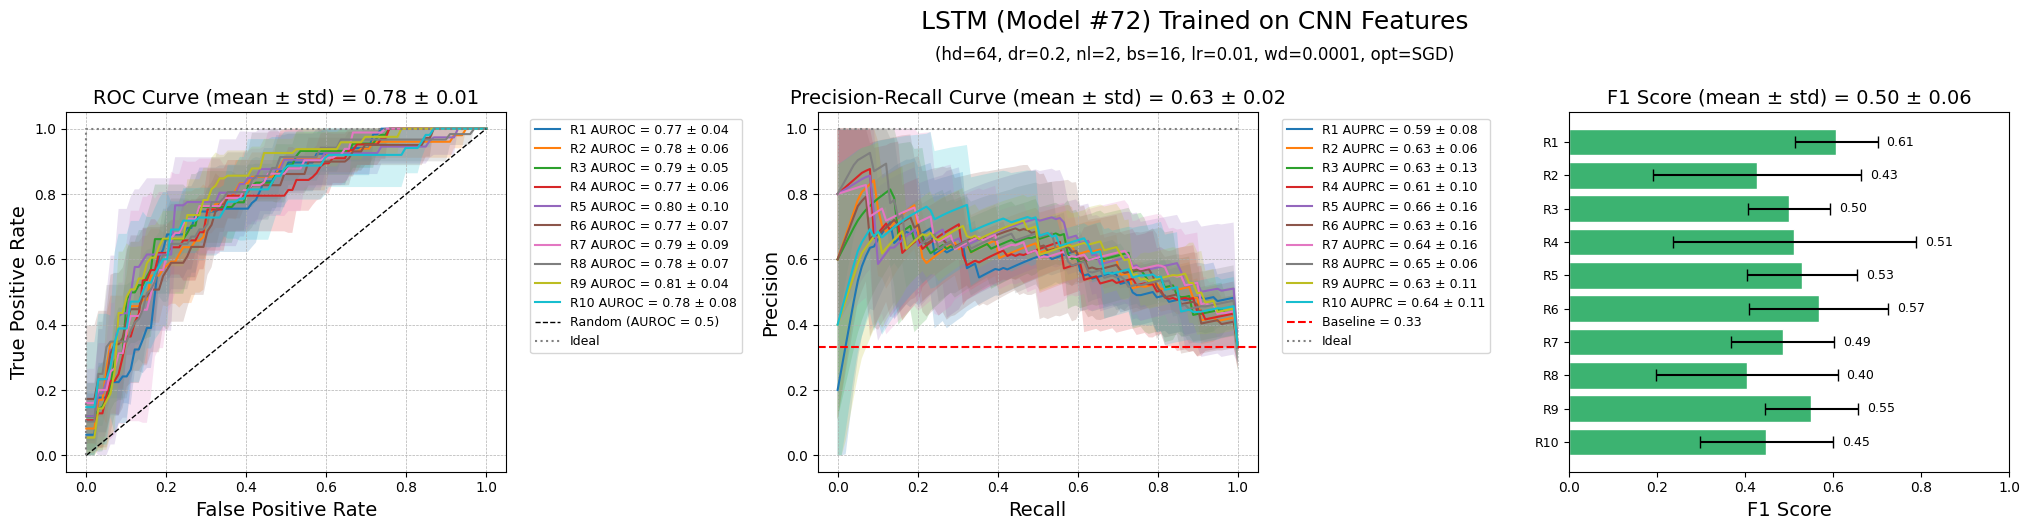

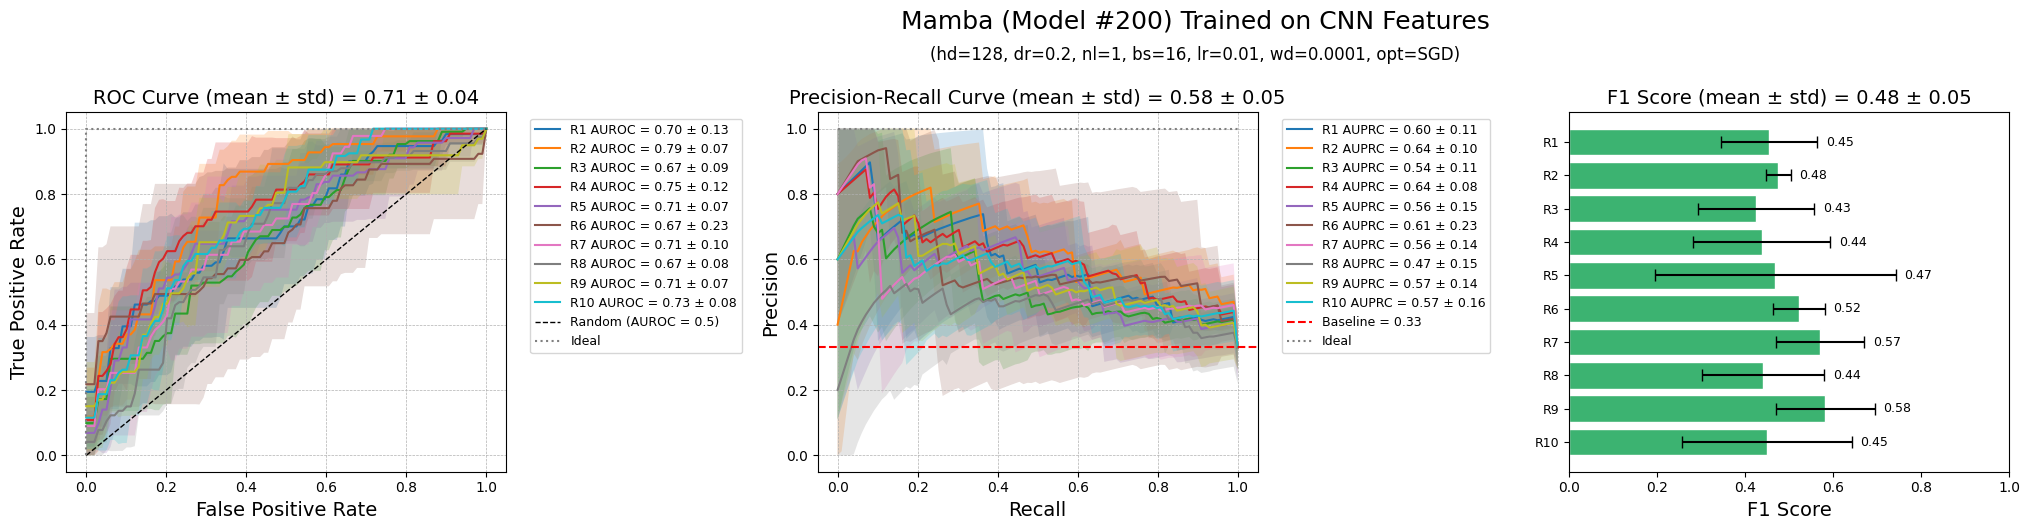

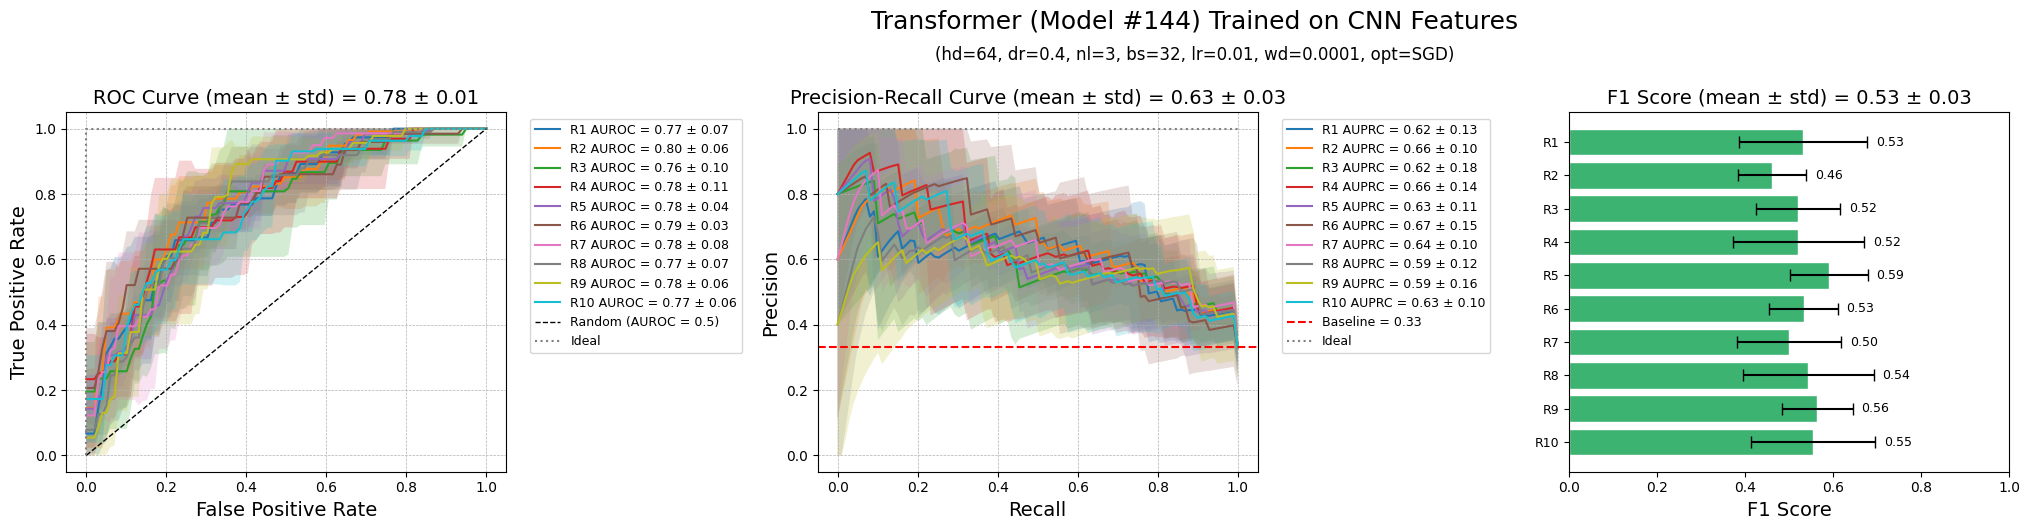

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc, average_precision_score, f1_score, precision_recall_curve
from collections import defaultdict

# Paths
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_cv_predictions(Stats)_4.json"
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_cv_predictions(CNN)_4.json"
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_cv_predictions(Stats_CNN)_4.json"

# save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(Stats)"
# save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(CNN)"
save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/TrainSet_Classification(StatsCNN)"

os.makedirs(save_dir, exist_ok=True)

# ====== Load data ======
with open(file_path, "r") as f:
    data = json.load(f)
all_y_true = np.concatenate([entry["y_true"] for entry in data])
global_baseline = np.mean(all_y_true)

# ====== Group by config ======
grouped = defaultdict(list)
for entry in data:
    config_key = (
        entry['model'], entry['hidden_dim'], entry['dropout'], entry['num_layers'],
        entry['batch_size'], entry['lr'], entry['weight_decay'], entry['optimizer']
    )
    grouped[config_key].append(entry)

# ====== Get top config per model ======
model_counters = defaultdict(int)
model_scores = defaultdict(list)

for config_key in grouped:
    model_type = config_key[0]
    model_counters[model_type] += 1
    model_id = f"{model_type} (Model #{model_counters[model_type]})"

    repeats = defaultdict(list)
    for e in grouped[config_key]:
        repeats[e['repeat']].append(e)

    auprcs = [average_precision_score(e["y_true"], e["y_prob"])
              for r_entries in repeats.values() for e in r_entries]
    model_scores[model_type].append((np.mean(auprcs), config_key, model_id))

top_configs = []
for model_type, models in model_scores.items():
    top_models = sorted(models, key=lambda x: -x[0])[:1]
    for _, config_key, model_id in top_models:
        top_configs.append((model_id, config_key))

# ====== Plotting function ======
def plot_model(model_id, config_key, top_rank):
    entries = grouped[config_key]
    repeats = defaultdict(list)
    for e in entries:
        repeats[e['repeat']].append(e)

    all_fpr = np.linspace(0, 1, 100)
    all_recall = np.linspace(0, 1, 100)
    repeat_roc_data, repeat_prc_data = [], []
    f1_means, f1_stds = [], []

    for repeat_idx, r in enumerate(sorted(repeats)):
        tpr_list, precision_list = [], []
        aurocs, auprcs, f1s = [], [], []

        for entry in repeats[r]:
            y_true = np.array(entry["y_true"])
            y_prob = np.array(entry["y_prob"])
            y_pred = (y_prob >= 0.5).astype(int)

            if len(np.unique(y_true)) < 2:
                continue

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            interp_tpr = np.clip(np.interp(all_fpr, fpr, tpr), 0, 1)
            tpr_list.append(interp_tpr)
            aurocs.append(auc(fpr, tpr))

            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            interp_precision = np.clip(np.interp(all_recall, recall[::-1], precision[::-1]), 0, 1)
            precision_list.append(interp_precision)
            auprcs.append(average_precision_score(y_true, y_prob))

            f1s.append(f1_score(y_true, y_pred))

        if aurocs:
            repeat_roc_data.append((repeat_idx + 1, tpr_list, np.mean(aurocs), np.std(aurocs)))
            repeat_prc_data.append((repeat_idx + 1, precision_list, all_recall,
                                    np.mean(auprcs), np.std(auprcs)))
            f1_means.append(np.mean(f1s))
            f1_stds.append(np.std(f1s))

    if len(repeat_roc_data) < 3:
        return

    fig, axs = plt.subplots(1, 3, figsize=(24, 5))

    # --- ROC ---
    for r_idx, tprs, r_mean, r_std in repeat_roc_data:
        mean_tpr = np.mean(tprs, axis=0)
        std_tpr = np.std(tprs, axis=0)
        axs[0].plot(all_fpr, mean_tpr, label=f"R{r_idx} AUROC = {r_mean:.2f} ± {r_std:.2f}", lw=1.5)
        axs[0].fill_between(all_fpr,
                            np.clip(mean_tpr - std_tpr, 0, 1),
                            np.clip(mean_tpr + std_tpr, 0, 1), alpha=0.2)
    axs[0].plot([0, 1], [0, 1], 'k--', lw=1, label="Random (AUROC = 0.5)")
    axs[0].plot([0, 0, 1], [0, 1, 1], color='gray', linestyle=':', lw=1.5, label="Ideal")
    roc_vals = [x[2] for x in repeat_roc_data]
    axs[0].set_title(f"ROC Curve (mean ± std) = {np.mean(roc_vals):.2f} ± {np.std(roc_vals):.2f}", fontsize=14)
    axs[0].set_xlabel("False Positive Rate", fontsize=14)
    axs[0].set_ylabel("True Positive Rate", fontsize=14)
    axs[0].grid(True, linestyle='--', linewidth=0.5)
    axs[0].legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.04, 1))

    # --- PRC ---
    for r_idx, precisions, r_curve, pr_mean, pr_std in repeat_prc_data:
        mean_precision = np.mean(precisions, axis=0)
        std_precision = np.std(precisions, axis=0)
        axs[1].plot(r_curve, mean_precision, label=f"R{r_idx} AUPRC = {pr_mean:.2f} ± {pr_std:.2f}", lw=1.5)
        axs[1].fill_between(r_curve,
                            np.clip(mean_precision - std_precision, 0, 1),
                            np.clip(mean_precision + std_precision, 0, 1), alpha=0.2)
    axs[1].axhline(y=global_baseline, color="red", linestyle="--", linewidth=1.5,
                   label=f"Baseline = {global_baseline:.2f}")
    axs[1].plot([0, 1], [1, 1], color='gray', linestyle=':', lw=1.5, label="Ideal")
    pr_vals = [x[3] for x in repeat_prc_data]
    axs[1].set_title(f"Precision-Recall Curve (mean ± std) = {np.mean(pr_vals):.2f} ± {np.std(pr_vals):.2f}", fontsize=14)
    axs[1].set_xlabel("Recall", fontsize=14)
    axs[1].set_ylabel("Precision", fontsize=14)
    axs[1].grid(True, linestyle='--', linewidth=0.5)
    axs[1].legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.04, 1))

    # --- F1 ---
    x = np.arange(1, len(f1_means) + 1)
    y_pos = np.arange(len(f1_means))[::-1]  # Reverse order for top-to-bottom
    f1_means_reversed = f1_means[::-1]
    f1_stds_reversed = f1_stds[::-1]

    axs[2].barh(y_pos, f1_means_reversed, xerr=f1_stds_reversed, capsize=4, color='mediumseagreen', edgecolor='white')

    # Add value labels
    for i, (v, s) in zip(y_pos, zip(f1_means_reversed, f1_stds_reversed)):
        axs[2].text(v + s + 0.02, i, f"{v:.2f}", va='center', fontsize=9)

    # Set y-ticks and labels
    axs[2].set_yticks(y_pos)
    axs[2].set_yticklabels([f"R{i}" for i in x], fontsize=9)
    axs[2].set_xlim(0, 1)
    axs[2].set_xlabel("F1 Score", fontsize=14)
    axs[2].set_title(f"F1 Score (mean ± std) = {np.mean(f1_means):.2f} ± {np.std(f1_means):.2f}", fontsize=14)

    # Title
    # fig.suptitle(f"{model_id} Trained on Stats Features", fontsize=18, y=1.05)
    # fig.suptitle(model_id, fontsize=18, y=1.05)
    fig.suptitle(f"{model_id} Trained on CNN Features", fontsize=18, y=1.05)

    config_str = f"(hd={config_key[1]}, dr={config_key[2]}, nl={config_key[3]}, bs={config_key[4]}, lr={config_key[5]}, wd={config_key[6]}, opt={config_key[7]})"
    fig.text(0.5, 0.95, config_str, ha='center', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    # # Save if needed:
    # fname_base = os.path.join(save_dir, f"{model_id.replace(' ', '_')}_Top{top_rank}")
    # plt.savefig(fname_base + ".png", dpi=600, bbox_inches='tight')
    # plt.savefig(fname_base + ".pdf", dpi=600, bbox_inches='tight')
    # plt.close()

# ====== Run plotting ======
top_indices = defaultdict(int)
for model_id, config_key in top_configs:
    model_type = model_id.split(" ")[0]
    top_indices[model_type] += 1
    plot_model(model_id, config_key, top_indices[model_type])

##### Classification Test Plots

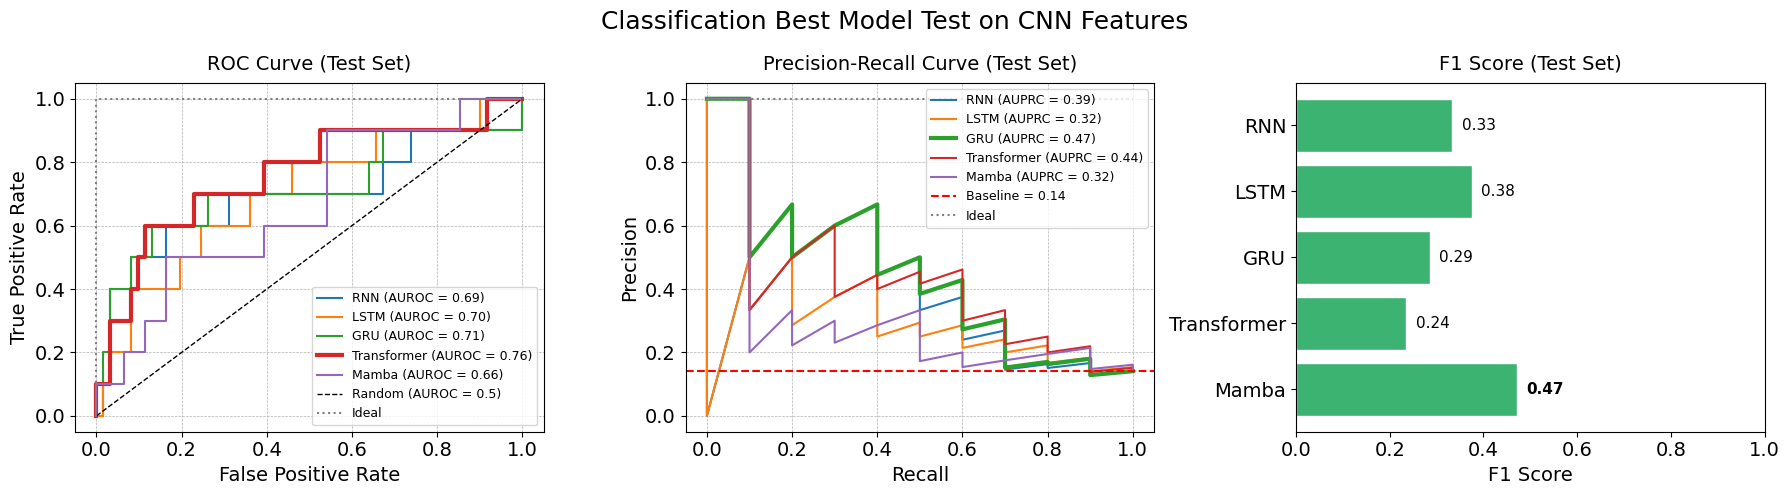

In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, auc, average_precision_score, f1_score, precision_recall_curve
from matplotlib import rcParams

# === Configuration ===
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_best_model_test_predictions(Stats)_4.json"
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_best_model_test_predictions(CNN)_4.json"
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels/Classification_best_model_test_predictions(Stats_CNN)_4.json"

save_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig8_ClassificationModels"
os.makedirs(save_dir, exist_ok=True)

# === Font & Figure Settings ===
rcParams['font.family'] = 'sans-serif'
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 9
rcParams['axes.titlesize'] = 14

FIG_WIDTH = 18
FIG_HEIGHT = 5

# === Load and Organize Data ===
with open(file_path, "r") as f:
    data = json.load(f)

model_data = {}
all_y_true = []
for entry in data:
    model = entry["model"]
    y_true = np.array(entry["y_true"])
    y_prob = np.array(entry["y_prob"])
    model_data[model] = {"y_true": y_true, "y_prob": y_prob}
    all_y_true.append(y_true)

# === Global baseline ===
global_y_true = np.concatenate(all_y_true)
baseline = np.mean(global_y_true)

# === Preprocess metrics ===
model_names_order = ["RNN", "LSTM", "GRU", "Transformer", "Mamba"]
auprc_scores, f1_scores, roc_data, prc_data = [], [], {}, {}

for model in model_names_order:
    y_true = model_data[model]["y_true"]
    y_prob = model_data[model]["y_prob"]
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[model] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    # AUPRC and PRC curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    auprc_scores.append(auprc)
    prc_data[model] = {"precision": precision, "recall": recall, "auprc": auprc}

    # F1
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)

# === Create composite figure (1x3) ===
fig, axs = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))
fig.subplots_adjust(wspace=0.35)  # increase space between the 3 panels

# --- ROC Curve ---
best_idx_roc = np.argmax([v["auc"] for v in roc_data.values()])
for i, model in enumerate(model_names_order):
    roc = roc_data[model]
    lw = 3 if i == best_idx_roc else 1.5
    axs[0].plot(roc["fpr"], roc["tpr"], label=f"{model} (AUROC = {roc['auc']:.2f})", lw=lw)
axs[0].plot([0, 1], [0, 1], 'k--', lw=1, label="Random (AUROC = 0.5)")
axs[0].plot([0, 0, 1], [0, 1, 1], color='gray', linestyle=':', lw=1.5, label="Ideal")
axs[0].set_xlabel("False Positive Rate")
axs[0].set_ylabel("True Positive Rate")
axs[0].set_title("ROC Curve (Test Set)", pad=10)
axs[0].grid(True, linestyle='--', linewidth=0.5)
# axs[0].legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
axs[0].legend(loc="lower right")

# --- AUPRC Curve Plot ---
best_idx_pr = np.argmax(auprc_scores)
for i, model in enumerate(model_names_order):
    pr = prc_data[model]
    lw = 3 if i == best_idx_pr else 1.5
    axs[1].plot(pr["recall"], pr["precision"], label=f"{model} (AUPRC = {pr['auprc']:.2f})", lw=lw)
axs[1].axhline(y=baseline, color="red", linestyle="--", linewidth=1.5, label=f"Baseline = {baseline:.2f}")
axs[1].plot([0, 1], [1, 1], color='gray', linestyle=':', lw=1.5, label="Ideal")
axs[1].set_xlabel("Recall")
axs[1].set_ylabel("Precision")
axs[1].set_title("Precision-Recall Curve (Test Set)", pad=10)
axs[1].grid(True, linestyle='--', linewidth=0.5)
# axs[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
axs[1].legend(loc="upper right")

# --- F1 Score Horizontal Bar Plot ---
y_pos = np.arange(len(model_names_order))[::-1]
f1_scores_reversed = f1_scores[::-1]
axs[2].barh(y_pos, f1_scores_reversed, color='mediumseagreen', edgecolor='white')
best_idx_f1 = np.argmax(f1_scores)
for i, v in zip(y_pos, f1_scores_reversed):
    fontweight = 'bold' if f1_scores.index(v) == best_idx_f1 else 'normal'
    axs[2].text(v + 0.02, i, f"{v:.2f}", va='center', fontsize=11, fontweight=fontweight)
axs[2].set_yticks(y_pos)
axs[2].set_yticklabels(model_names_order)
axs[2].set_xlim(0, 1)
axs[2].set_xlabel("F1 Score")
axs[2].set_title("F1 Score (Test Set)", pad=10)

# fig.suptitle("Classification Best Model Test on Stats Features", fontsize=18)
# fig.suptitle("Classification Best Model Test", fontsize=18)
fig.suptitle("Classification Best Model Test on CNN Features", fontsize=18)

plt.tight_layout()
plt.show()

# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(Stats).png"), dpi=600)
# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(CNN).png"), dpi=600)
# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(StatsCNN).png"), dpi=600)

# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(Stats).pdf"), dpi=600)
# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(CNN).pdf"), dpi=600)
# plt.savefig(os.path.join(save_dir, "TestSet_Classification_BestModels(StatsCNN).pdf"), dpi=600)
# plt.close()


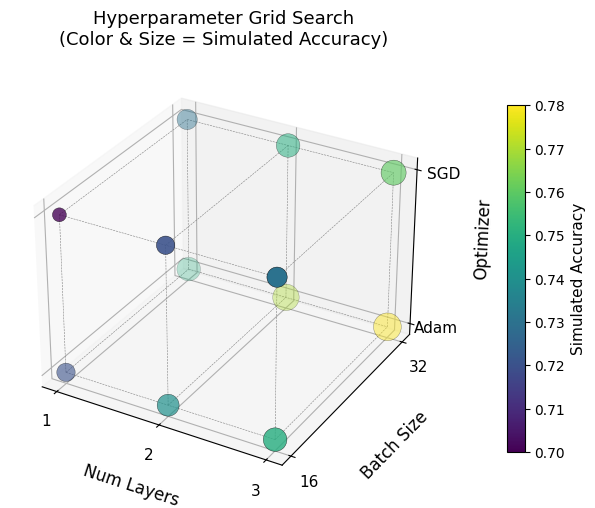

In [74]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Hyperparameter values
num_layers_list = [1, 2, 3]              # x-axis
batch_sizes = [16, 32]                   # y-axis
optimizers = ["Adam", "SGD"]             # z-axis (categorical)

# Map optimizer to numeric z-axis
optimizer_to_z = {opt: i for i, opt in enumerate(optimizers)}

# Simulated performance
points = []
accuracies = []

for nl in num_layers_list:
    for b in batch_sizes:
        for opt in optimizers:
            x = nl
            y = b
            z = optimizer_to_z[opt]
            # Simulate accuracy
            acc = (
                0.70 +
                0.03 * (b == 32) +
                0.02 * (nl == 2) + 0.03 * (nl == 3) +
                0.02 * (opt == "Adam")
            )
            points.append((x, y, z))
            accuracies.append(acc)

# Convert to arrays
points = np.array(points)
accuracies = np.array(accuracies)
X, Y, Z = points[:, 0], points[:, 1], points[:, 2]
R = accuracies

# Normalize for color and size
R_norm = (R - R.min()) / (R.max() - R.min())
sizes = 100 + 300 * R_norm

# Plot
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X, Y, Z, c=R, s=sizes, cmap='viridis', edgecolor='black', linewidth=0.3)

# Grid lines
for nl in num_layers_list:
    for b in batch_sizes:
        zs = list(optimizer_to_z.values())
        xs = [nl] * len(zs)
        ys = [b] * len(zs)
        ax.plot(xs, ys, zs, linestyle='dashed', color='gray', linewidth=0.4)

for nl in num_layers_list:
    for opt in optimizers:
        z = optimizer_to_z[opt]
        ys = batch_sizes
        xs = [nl] * len(ys)
        zs = [z] * len(ys)
        ax.plot(xs, ys, zs, linestyle='dashed', color='gray', linewidth=0.4)

for b in batch_sizes:
    for opt in optimizers:
        z = optimizer_to_z[opt]
        xs = num_layers_list
        ys = [b] * len(xs)
        zs = [z] * len(xs)
        ax.plot(xs, ys, zs, linestyle='dashed', color='gray', linewidth=0.4)

# Axis formatting
ax.set_xticks(num_layers_list)
ax.set_xticklabels([str(nl) for nl in num_layers_list], fontsize=11)
ax.set_yticks(batch_sizes)
ax.set_yticklabels([str(b) for b in batch_sizes], fontsize=11)
ax.set_zticks(list(optimizer_to_z.values()))
ax.set_zticklabels(optimizers, fontsize=11)

ax.set_xlabel('Num Layers', fontsize=12, labelpad=10)
ax.set_ylabel('Batch Size', fontsize=12, labelpad=10)
ax.set_zlabel('Optimizer', fontsize=12, labelpad=10)
ax.set_title('Hyperparameter Grid Search\n(Color & Size = Simulated Accuracy)', fontsize=13, pad=15)

# Colorbar
cb = fig.colorbar(sc, ax=ax, shrink=0.7, aspect=20, pad=0.12)
cb.set_label('Simulated Accuracy', fontsize=11)
cb.ax.tick_params(labelsize=10)

# Layout and export
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
fig.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/grid_plot.png", dpi=600, bbox_inches='tight', transparent=True)
fig.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/grid_plot.pdf", dpi=600, bbox_inches='tight', transparent=True)
plt.show()


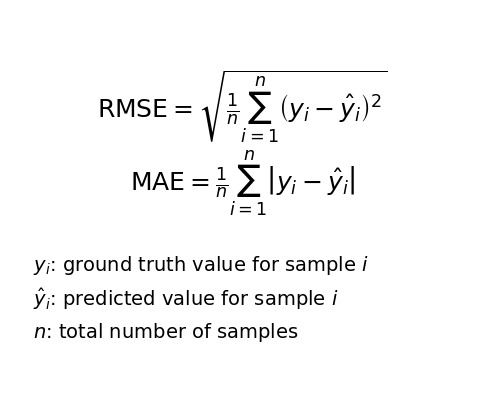

In [75]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(6, 5))

# RMSE equation
plt.text(0.5, 0.75, r'$\mathrm{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2}$',
         fontsize=18, ha='center', va='center')

# MAE equation
plt.text(0.5, 0.55, r'$\mathrm{MAE} = \frac{1}{n} \sum_{i=1}^n \left| y_i - \hat{y}_i \right|$',
         fontsize=18, ha='center', va='center')

# Legend (left-aligned)
legend_text = (
    r'$y_i$: ground truth value for sample $i$' '\n'
    r'$\hat{y}_i$: predicted value for sample $i$' '\n'
    r'$n$: total number of samples'
)
plt.text(0.05, 0.25, legend_text,
         fontsize=14, ha='left', va='center', linespacing=1.5)

# Turn off axes
plt.axis('off')

# Save high-resolution image
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/rmse_mae_formula.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/rmse_mae_formula.pdf", dpi=600, bbox_inches='tight', transparent=True)
plt.show()


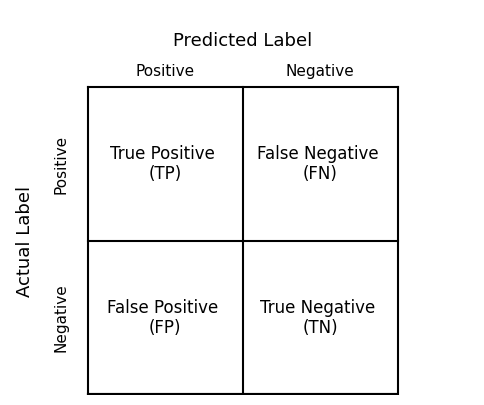

In [76]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(6, 5))

# Draw grid
ax.plot([0.01, 1.99], [1, 1], 'k-', linewidth=3)  # bottom horizontal
ax.plot([0, 2], [2, 2], 'k-')  # middle horizontal
ax.plot([0, 2], [3, 3], 'k-')  # top horizontal ← NEW
ax.plot([1, 1], [1, 3], 'k-')  # vertical center
ax.plot([0, 0], [1, 3], 'k-')  # left vertical
ax.plot([2, 2], [1, 3], 'k-')  # right vertical

# Fill labels
ax.text(0.5, 2.5, 'True Positive \n(TP)', ha='center', va='center', fontsize=12)
ax.text(1.5, 2.5, 'False Negative \n(FN)', ha='center', va='center', fontsize=12)
ax.text(0.5, 1.5, 'False Positive \n(FP)', ha='center', va='center', fontsize=12)
ax.text(1.5, 1.5, 'True Negative \n(TN)', ha='center', va='center', fontsize=12)

# Axis labels (move farther from tick text)
ax.text(1, 3.3, 'Predicted Label', ha='center', va='center', fontsize=13)
ax.text(-0.4, 2, 'Actual Label', ha='center', va='center', fontsize=13, rotation=90)

# Tick text (move closer to plot center)
ax.text(0.5, 3.1, 'Positive', ha='center', va='center', fontsize=11)
ax.text(1.5, 3.1, 'Negative', ha='center', va='center', fontsize=11)
ax.text(-0.125, 2.5, 'Positive', ha='right', va='center', fontsize=11, rotation=90)
ax.text(-0.125, 1.5, 'Negative', ha='right', va='center', fontsize=11, rotation=90)

# Hide axes
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(1, 3.5)
ax.axis('off')

# Save high-resolution image
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/confusion_matrix.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/Fig1_Workflow/icons/confusion_matrix.pdf", dpi=600, bbox_inches='tight', transparent=True)
plt.show()
